# Crypto API Runner Project

In [16]:
import os
from time import sleep
import pandas as pd
import json
from requests import session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
def api_runner():
    global df
    
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    
    parameters = {
        'start': '1',
        'limit': '20',
        'convert': 'USD'
    }
    
    Headers = {
        'Accept': 'application/json',
        'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }
    
    session_obj = session()
    session_obj.headers.update(Headers)
    
    try:
        response = session_obj.get(url, params=parameters)
        data = json.loads(response.text)
        print("Status code:", response.status_code)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
        print(e)
        return
    
    df2 = pd.json_normalize(data['data'])
    df2['timestamp'] = pd.to_datetime('now')
    
    # Append
    df = pd.concat([df, df2], ignore_index=True)
    
    # Save to CSV
    file_path = r'C:\Users\wijks\Documents\Data Analyst Portfolio\Crypto Checker Api Project\csv\API.csv'
    
    if not os.path.isfile(file_path):
        df.to_csv(file_path, index=False)
    else:
        df.to_csv(file_path, mode='a', header=False, index=False)
    
    print(f"Data appended at {pd.to_datetime('now')}")

In [3]:
# Initialize
df = pd.json_normalize(data['data']) if 'data' in globals() else pd.DataFrame()
df['timestamp'] = pd.to_datetime('now')
print("Initial df created with", len(df), "rows")

Initial df created with 0 rows


In [4]:
for i in range(5):          # 5 iterations for this test (MAX 333/day)
    api_runner()
    print(f'API Runner Completed Successfully - Iteration {i+1}')
    sleep(60)  # 1 minut

Status code: 200
Data appended at 2026-08-04 15:56:07.652273
API Runner Completed Successfully - Iteration 1
Status code: 200
Data appended at 2026-08-04 15:57:07.834601
API Runner Completed Successfully - Iteration 2
Status code: 200
Data appended at 2026-08-04 15:58:08.016003
API Runner Completed Successfully - Iteration 3
Status code: 200
Data appended at 2026-08-04 15:59:08.181219
API Runner Completed Successfully - Iteration 4
Status code: 200
Data appended at 2026-08-04 16:00:08.362087
API Runner Completed Successfully - Iteration 5


In [5]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
df

,timestamp,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,...,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address
0,2026-08-04 15:56:07.636469,1.00000,Bitcoin,BTC,bitcoin,False,20065646.00000,20065646.00000,21000000.00000,2010-07-13T00:00:00.000Z,...,1278812320572.29468,58.61860,1338360037449.98999,None,2026-08-04T13:55:00.000Z,NaN,NaN,NaN,NaN,NaN
1,2026-08-04 15:56:07.636469,1027.00000,Ethereum,ETH,ethereum,True,120682209.88957,120682209.88957,NaN,2015-08-07T00:00:00.000Z,...,224898778422.86163,10.30380,224898778422.85999,None,2026-08-04T13:55:00.000Z,NaN,NaN,NaN,NaN,NaN
2,2026-08-04 15:56:07.636469,825.00000,Tether USDt,USDT,tether,True,183285704315.72986,189097136389.37421,NaN,2015-02-25T00:00:00.000Z,...,183088463824.94946,8.38910,188893642002.70001,None,2026-08-04T13:54:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7
3,2026-08-04 15:56:07.636469,1839.00000,BNB,BNB,bnb,False,133164863.20000,133164863.20000,133164866.02000,2017-07-25T00:00:00.000Z,...,78493797347.34200,3.59890,78493799009.59000,None,2026-08-04T13:54:00.000Z,NaN,NaN,NaN,NaN,NaN
4,2026-08-04 15:56:07.636469,3408.00000,USDC,USDC,usd-coin,False,72062226938.23158,72062226938.23158,NaN,2018-10-08T00:00:00.000Z,...,72045632177.35399,3.29870,72045632177.35001,None,2026-08-04T13:53:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-08-04 16:00:08.354719,512.00000,Stellar,XLM,stellar,False,34290784064.40763,50001786839.91248,50001806812.00000,2014-08-05T00:00:00.000Z,...,5796346373.73386,0.26560,8452060794.25000,None,2026-08-04T13:58:00.000Z,NaN,NaN,NaN,NaN,NaN
96,2026-08-04 16:00:08.354719,4943.00000,Dai,DAI,multi-collateral-dai,True,4586407767.04372,4586407767.04372,NaN,2019-11-22T00:00:00.000Z,...,4583599143.00705,0.21010,4583599143.01000,None,2026-08-04T13:58:00.000Z,1027.00000,ethereum,Ethereum,ETH,0x6b175474e89094c44da98b954eedeac495271d0f
97,2026-08-04 16:00:08.354719,37263.00000,Canton,CC,canton-network,True,39254695399.07948,39254695399.07948,NaN,2025-07-08T04:07:45.000Z,...,4341537828.40054,0.19900,4341537828.40000,None,2026-08-04T13:59:00.000Z,NaN,NaN,NaN,NaN,NaN
98,2026-08-04 16:00:08.354719,1831.00000,Bitcoin Cash,BCH,bitcoin-cash,False,20070565.62500,20070565.62500,21000000.00000,2017-07-23T00:00:00.000Z,...,4283996509.59441,0.19640,4482381233.41000,None,2026-08-04T13:58:00.000Z,NaN,NaN,NaN,NaN,NaN


In [6]:
# Grouping
df3 = df.groupby('name', sort = False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h', 'quote.USD.percent_change_7d', 'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d', 'quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.33812,0.81822,1.03436,1.45724,4.57577,-22.09503
Ethereum,-0.66552,0.43124,-0.48877,5.49999,14.69280,-21.42711
Tether USDt,-0.00353,0.01734,0.01015,-0.02040,-0.03137,-0.08917
BNB,-0.36887,0.37746,4.24927,0.44499,0.76349,-8.97566
USDC,0.00028,-0.00707,-0.00527,-0.00410,0.00208,-0.00235
XRP,-0.32891,0.00271,2.15082,-5.41484,-3.07033,-24.63150
Solana,-0.20832,0.89294,1.37104,-9.20610,13.79121,-16.57905
TRON,-0.05325,0.76324,1.57216,0.39855,1.38878,-4.31326
Hyperliquid,-0.73369,3.31388,1.81424,-20.22724,-9.76820,25.68082


In [7]:
# Stacking
df4 = df3.stack()
df4

name                                                     
Bitcoin                      quote.USD.percent_change_1h    -0.33812
                             quote.USD.percent_change_24h    0.81822
                             quote.USD.percent_change_7d     1.03436
                             quote.USD.percent_change_30d    1.45724
                             quote.USD.percent_change_60d    4.57577
                                                              ...   
World Liberty Financial USD  quote.USD.percent_change_24h    0.02067
                             quote.USD.percent_change_7d     0.03147
                             quote.USD.percent_change_30d    0.02272
                             quote.USD.percent_change_60d    0.03904
                             quote.USD.percent_change_90d   -0.02743
Length: 120, dtype: float64

In [8]:
df5 = df4.to_frame(name = 'values')
df5

values
name                                                             
Bitcoin                     quote.USD.percent_change_1h  -0.33812
                            quote.USD.percent_change_24h  0.81822
                            quote.USD.percent_change_7d   1.03436
                            quote.USD.percent_change_30d  1.45724
                            quote.USD.percent_change_60d  4.57577
...                                                           ...
World Liberty Financial USD quote.USD.percent_change_24h  0.02067
                            quote.USD.percent_change_7d   0.03147
                            quote.USD.percent_change_30d  0.02272
                            quote.USD.percent_change_60d  0.03904
                            quote.USD.percent_change_90d -0.02743

[120 rows x 1 columns]

In [9]:
df5.count()

values    120
dtype: int64

In [10]:
# Give index

index = pd.Index(range(120))

#df6 = df5.set_index(index)
df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.33812
1,Bitcoin,quote.USD.percent_change_24h,0.81822
2,Bitcoin,quote.USD.percent_change_7d,1.03436
3,Bitcoin,quote.USD.percent_change_30d,1.45724
4,Bitcoin,quote.USD.percent_change_60d,4.57577
...,...,...,...
115,World Liberty Financial USD,quote.USD.percent_change_24h,0.02067
116,World Liberty Financial USD,quote.USD.percent_change_7d,0.03147
117,World Liberty Financial USD,quote.USD.percent_change_30d,0.02272
118,World Liberty Financial USD,quote.USD.percent_change_60d,0.03904


In [11]:
df7 = df6.rename(columns = {'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.33812
1,Bitcoin,quote.USD.percent_change_24h,0.81822
2,Bitcoin,quote.USD.percent_change_7d,1.03436
3,Bitcoin,quote.USD.percent_change_30d,1.45724
4,Bitcoin,quote.USD.percent_change_60d,4.57577
...,...,...,...
115,World Liberty Financial USD,quote.USD.percent_change_24h,0.02067
116,World Liberty Financial USD,quote.USD.percent_change_7d,0.03147
117,World Liberty Financial USD,quote.USD.percent_change_30d,0.02272
118,World Liberty Financial USD,quote.USD.percent_change_60d,0.03904


In [12]:
# Cleaning up percent_change values
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,-0.33812
1,Bitcoin,24h,0.81822
2,Bitcoin,7d,1.03436
3,Bitcoin,30d,1.45724
4,Bitcoin,60d,4.57577
...,...,...,...
115,World Liberty Financial USD,24h,0.02067
116,World Liberty Financial USD,7d,0.03147
117,World Liberty Financial USD,30d,0.02272
118,World Liberty Financial USD,60d,0.03904


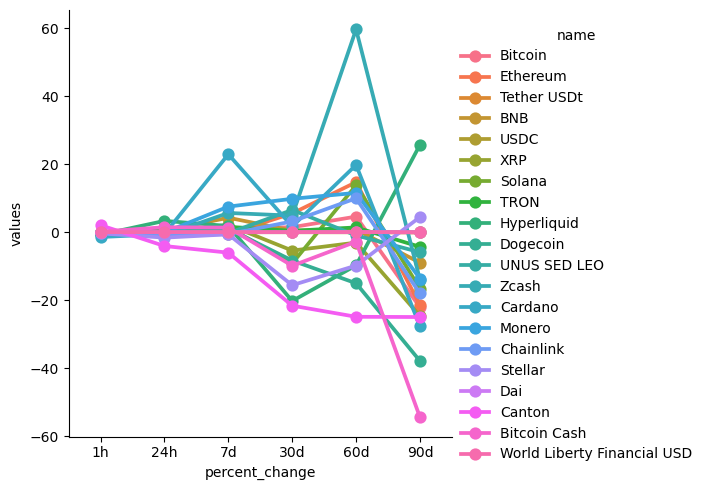

In [13]:
# Visualization
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [14]:
# See price change for wished for coin/crypto from API Runner
df10 = df[['name', 'quote.USD.price', 'timestamp']].query("name == 'Dogecoin'") # change this crypto name to see viz below
print(df10)

        name  quote.USD.price                  timestamp
9   Dogecoin          0.07021 2026-08-04 15:56:07.636469
29  Dogecoin          0.07020 2026-08-04 15:57:07.829513
49  Dogecoin          0.07020 2026-08-04 15:58:08.009913
69  Dogecoin          0.07012 2026-08-04 15:59:08.174965
89  Dogecoin          0.07012 2026-08-04 16:00:08.354719


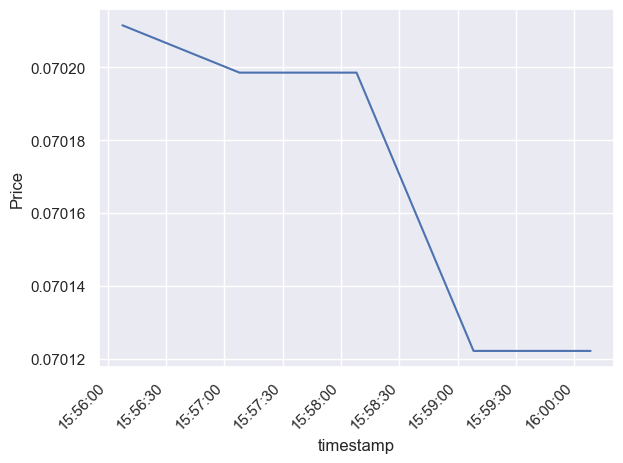

In [19]:
# Visualization of coin above
sns.set_theme(style="darkgrid")

ax = sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)

# Change the y-axis label
ax.set_ylabel("Price")

# Make timestamps readable
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  # show only time
plt.xticks(rotation = 45, ha='right')  # rotate labels
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# prevent label cutoff
plt.tight_layout()  
plt.show()
